How does age distribution differ between endurance types (marathon vs ultramarathon)?

Unlike Track and Field running events, 100m, 200, 5000m, and 10,000m. Endurance events often have a disproportionate amount of older athletes (30s, 40s, 50s, 60s, etc)

I have chosen the Marathon to be the base line of shorter distances since most consider that distance to be the ultimate distance, but it is not. There are also Ultra Marathons.

I have chosen 2 datasets, one for each type of endurance event. 

<div class="alert alert-block alert-info">
<b>For the Marathon I have chosen a dataset simplely called 2010-2019 Fall Marathons. This dataset was originally 109.7+ MB and has been reduced to the years 2016-2019. This cut it down to 385.6+ MB. Nulls were then dropped leaving 215.4+ MB. The full dataset can be found at https://www.kaggle.com/datasets/runningwithrock/2010-2019-fall-marathons</b> 
</div>

I researched and found that the youngest person to run a marathon was Umi Taguchi at age 17 at the 2024 Honolulu Marathon. Dropped ages younger than 17.

Through research, the oldest person to run a marathon was Dimitrios Yordanidis in 1976 at age 98. Dropped ages older than 98.

<div class="alert alert-block alert-success">
<b>For the Ultra Marathon dataset I have chosen a dataset of over 7 million race records from 1798-2022. This dataset came in at 740+ MB and was trimmed to years 2016-2022. Since the Event dates were in Day, Month, Year format they were converted to datetime. Doing this left the dataset at 169.5+ MB. Since the Marathon data set covered Fall races, the Ultra Marathon dataset was reduced to fall races (Sept to end of year). Finally taking the dataset to 33.9+ MB. The full dataset can be found at https://www.kaggle.com/datasets/aiaiaidavid/the-big-dataset-of-ultra-marathon-running/data</b> 
</div>

I did not cut ages from the Ultra Marathon list since during the previously mentioned date range there were no finishers younger than 20 and only 2 aged 85 and 1 aged 90. 

In the Ultra Marathon, I've heard rumors of a 100 year old finishing a 50 mile race, and as of 2025, 80 year old Bob Becker completed the 135 mile Badwater Ultra that runs through Death Valley in July.

With distances over 26.2, I expelct the patients and experience to play a factor into the age diferences between the two data sets. I expect the oldest person to finish the event to be from the Ultra Marathon data set. I also expect the average ages to be older in the Ultra Marahon data set from 50 miles and longer, this would encompance cut-off times of 13 hours and up. The average cut-off 50 mile race is 13-15 hours. 

<div class="alert alert-block alert-warning">
<b>I will compare my age to the average marathoner and ultra marathoner age during the timeframs listed above<b>
</div>


In [219]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px

In [220]:
import sys
print(sys.executable)


/Users/justinmasters/Documents/DA_prereq_Justin_Masters/Notebooks/Age_and_Endurance/env/bin/python


<div class="alert alert-block alert-info">
<b>__Import Results_marathon.csv__</b> 
</div>



In [221]:
marathon_df = pd.read_csv("Data/Results_marathon.csv")
marathon_df.tail()
#

,Race,Year,Name,Gender,Age,Finish,Age Bracket
779280,Marine Corps Marathon,2019,Daryl Young,M,39,18575,35-39
779281,Marine Corps Marathon,2019,Ella Biggins,F,24,18575,Under 35
779282,Marine Corps Marathon,2019,Kevin Klym,M,44,18575,40-44
779283,Marine Corps Marathon,2019,Casey A Shapiro,F,34,18578,Under 35
779284,Marine Corps Marathon,2019,Zhaowei Liu,M,64,18578,60-64


In [222]:
unique_year = marathon_df['Year'].unique
unique_year

<bound method Series.unique of 0         2019
1         2019
2         2019
3         2019
4         2019
          ... 
779280    2019
779281    2019
779282    2019
779283    2019
779284    2019
Name: Year, Length: 779285, dtype: int64>

In [223]:
sorted_year = marathon_df.sort_values(by='Year', ascending=False)
print(sorted_year)

                     Race  Year                     Name Gender  Age  Finish  \
0       Richmond Marathon  2019             DAWN STADNYK      F   43   12847   
431972   Chicago Marathon  2019             Thomas Ruddy      M   44   15463   
431979   Chicago Marathon  2019  Nestor Hugo Oliva Nervi      M   59   15466   
431978   Chicago Marathon  2019              Lee Chin Te      M   59   15465   
431977   Chicago Marathon  2019             Heesul Hwang      M   64   15464   
...                   ...   ...                      ...    ...  ...     ...   
563719       NYC Marathon  2016         Alberto Carletto      M   42   18257   
563718       NYC Marathon  2016              Maxine Swan      F   45   18257   
563717       NYC Marathon  2016               Kurt Weare      M   40   18257   
563716       NYC Marathon  2016                Emily Mee      F   25   18257   
389642   Chicago Marathon  2016            Cat Von Black      F   44   21456   

       Age Bracket  
0            40-44

In [224]:
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779285 entries, 0 to 779284
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Race         779285 non-null  object
 1   Year         779285 non-null  int64 
 2   Name         779285 non-null  object
 3   Gender       779280 non-null  object
 4   Age          779285 non-null  int64 
 5   Finish       779285 non-null  int64 
 6   Age Bracket  779285 non-null  object
dtypes: int64(3), object(4)
memory usage: 41.6+ MB


In [225]:
marathon_df.shape

(779285, 7)

In [226]:
#drop ages younger than 17 and older than 98


def official_ages(marathon_df):
    valid_ages = (marathon_df['Age'] >= 17) & (marathon_df['Age'] <= 98)
    official_ages = marathon_df[valid_ages]

    return official_ages

official_ages

<function __main__.official_ages(marathon_df)>

In [227]:
# verify ages were dropped

valid_age_range = official_ages(marathon_df)

unique_ages = sorted(valid_age_range['Age'].unique())
unique_ages


[np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(73),
 np.int64(74),
 np.int64(75),
 np.int64(76),
 np.int64(77),
 np.int64(78),
 np.int64(79),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(

In [228]:
# recheck nulls 

marathon_df.isnull().sum()


Race           0
Year           0
Name           0
Gender         5
Age            0
Finish         0
Age Bracket    0
dtype: int64

In [229]:
marathon_df = marathon_df.dropna()

In [230]:
# recheck nulls 

marathon_df.isnull().sum()

Race           0
Year           0
Name           0
Gender         0
Age            0
Finish         0
Age Bracket    0
dtype: int64

In [231]:
# Check if there are any duplicates

marathon_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
779280    False
779281    False
779282    False
779283    False
779284    False
Length: 779280, dtype: bool

In [232]:
# Rename Gender column to Sex

marathon_df.rename(columns={'Gender': 'Sex'}, inplace=True)
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779280 entries, 0 to 779284
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Race         779280 non-null  object
 1   Year         779280 non-null  int64 
 2   Name         779280 non-null  object
 3   Sex          779280 non-null  object
 4   Age          779280 non-null  int64 
 5   Finish       779280 non-null  int64 
 6   Age Bracket  779280 non-null  object
dtypes: int64(3), object(4)
memory usage: 47.6+ MB


In [233]:
# Assign Male and Female to M and F

marathon_df['Sex'] = marathon_df["Sex"].replace(['M', 'F'], ['Male', 'Female'])
marathon_df

,Race,Year,Name,Sex,Age,Finish,Age Bracket
0,Richmond Marathon,2019,DAWN STADNYK,Female,43,12847,40-44
1,Richmond Marathon,2019,ANDREW MARTIN,Male,27,12812,Under 35
2,Richmond Marathon,2019,CAROL BRAUN,Female,56,12844,55-59
3,Richmond Marathon,2019,PETER EMERSON,Male,29,12816,Under 35
4,Richmond Marathon,2019,JACOB BARKER,Male,18,12831,Under 35
...,...,...,...,...,...,...,...
779280,Marine Corps Marathon,2019,Daryl Young,Male,39,18575,35-39
779281,Marine Corps Marathon,2019,Ella Biggins,Female,24,18575,Under 35
779282,Marine Corps Marathon,2019,Kevin Klym,Male,44,18575,40-44
779283,Marine Corps Marathon,2019,Casey A Shapiro,Female,34,18578,Under 35


<div class="alert alert-block alert-success">
<b>__Import Results_um.csv__</b> 
</div>

In [234]:
um_df = pd.read_csv("Data/Results_um.csv")
um_df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:51 h,Team GG,RSA,1985.0,M,M23,5.381,266403
1,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:58 h,Team GG,GBR,1986.0,M,M23,5.381,266404
2,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:02 h,MAD Pat'S Brigade,GBR,1972.0,M,M45,4.386,266406
3,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:07 h,MAD Pat'S Brigade,GBR,1959.0,F,W55,4.386,266407
4,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:16:08 h,MAD Pat'S Brigade,GBR,1962.0,M,M55,4.368,266409


In [235]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
dtypes: float64(1), int64(3), obje

In [236]:
# verify years 

um_df['Year of event'].unique()

array([2018, 2016, 2017, 2019, 2020, 2021, 2022])

In [237]:
# Find the age categories

um_df['Athlete age category'].unique()

array(['M23', 'M45', 'W55', 'M55', 'W35', 'W23', 'M50', 'M35', 'M60',
       'W45', 'M40', 'MU23', 'W40', 'M65', 'M70', 'W50', 'W60', 'W65',
       'WU23', 'M85', 'W30', 'M20', 'M30', 'W20', 'M75', 'W70', 'W75',
       'M80', 'MU20', 'M90', 'W80', 'WU20'], dtype=object)

In [238]:
# Find birth years

um_df['Athlete year of birth'].unique()

array([1985., 1986., 1972., 1959., 1962., 1961., 1982., 1963., 1965.,
       1987., 1980., 1955., 1988., 1984., 1971., 1969., 1968., 1974.,
       1977., 1989., 1997., 1975., 1966., 1957., 1967., 1973., 1960.,
       1979., 1983., 1978., 1970., 1964., 1950., 1991., 1958., 1976.,
       1956., 1952., 1953., 1949., 1947., 1996., 1993., 1994., 1990.,
       1992., 1954., 1951., 1981., 1995., 1999., 2006., 2003., 2005.,
       1948., 2001., 1933., 1938., 1944., 1998., 2000., 1943., 1946.,
       2004., 1939., 1945., 2002., 1936., 1942., 1941., 1940., 1937.,
       1929., 1931., 1935., 1922., 1934., 2014., 2009., 2008., 2011.,
       2007., 2010.])

In [239]:
# Split Gender category into Athlete age category and Age

um_df['Gender category'] = um_df['Athlete age category'].str.extract(r'([A-Za-z]+)')
um_df['Age'] = um_df['Athlete age category'].str.extract(r'(\d+)').astype(int)


In [240]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Gender category            34

<div class="alert alert-block alert-success">
<b>Keep Age column and create Age Bracket</b> 
</div>

In [241]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Gender category            34

In [242]:
um_df['Age'].unique()

array([23, 45, 55, 35, 50, 60, 40, 65, 70, 85, 30, 20, 75, 80, 90])

In [243]:
# Drop Gender category

um_df = um_df.drop("Gender category", axis='columns')

In [244]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Age                        34

In [245]:
um_df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID,Age
0,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:51 h,Team GG,RSA,1985.0,M,M23,5.381,266403,23
1,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,19:41:58 h,Team GG,GBR,1986.0,M,M23,5.381,266404,23
2,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:02 h,MAD Pat'S Brigade,GBR,1972.0,M,M45,4.386,266406,45
3,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:10:07 h,MAD Pat'S Brigade,GBR,1959.0,F,W55,4.386,266407,55
4,2018,2018-09-21,Peak District Challenge - Gold Ultra 100km (GBR),106km,11,24:16:08 h,MAD Pat'S Brigade,GBR,1962.0,M,M55,4.368,266409,55


In [246]:
# Find the Distance and lenghts of races included

um_df['Event distance/length'].unique()

array(['106km', '80km', '50km', '40mi', '60km', '53km', '55km', '8h',
       '45km', '58km', '6h', '88km', '100km', '72km', '32mi', '30mi',
       '12h', '49.2km', '73km', '48km', '55.8km', '63.3km', '46km',
       '63km', '50mi', '57km', '105km', '45.2km', '105.6km', '129.8km',
       '81km', '158km/3Etappen', '45.4km', '48.5km', '45.1km', '45.5km',
       '46.6km', '35mi', '52km', '51.4km', '56km', '55.7km', '47km',
       '9:11h', '88km/2Etappen', '64km', '75km', '45mi', '85km', '65km',
       '45.8km', '370km/8Etappen', '112km', '52.4mi', '51mi', '34mi',
       '49km', '78km', '54km', '51km', '52.6km', '69km', '65.8km', '33mi',
       '61km', '63.6km', '101km', '64.6km', '55mi', '9h', '62km', '70km',
       '57.8km', '76km', '118km', '54.4km', '84km', '90km', '52mi',
       '50.9km', '103km', '60.2km', '103.5km', '173km/4Etappen', '11:43h',
       '45.18km', '57.2km', '67km', '24h', '67.4km', '85.6km', '132km',
       '97km', '47.6km', '110km', '66km', '15h', '51.5km', '83km',
    

In [247]:
# create new csv with changes 

um_df.to_csv('Results_um1.csv', index=False)

<div class="alert alert-block alert-warning">
<b>__Begin graphs__<b>
</div>


<div class="alert alert-block alert-info">
<b>Marathon</b> 
</div>

In [248]:
# find average age in fall marathons 2016*2019

average_age_by_year = marathon_df.groupby('Year')['Age'].mean()
average_age_by_year

Year
2016    39.765227
2017    40.511194
2018    39.364261
2019    39.563117
Name: Age, dtype: float64

<div class="alert alert-block alert-success">
<b>Ultra Marathon</b> 
</div>

In [249]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341390 entries, 0 to 341389
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              341390 non-null  int64  
 1   Event dates                341390 non-null  object 
 2   Event name                 341390 non-null  object 
 3   Event distance/length      341390 non-null  object 
 4   Event number of finishers  341390 non-null  int64  
 5   Athlete performance        341390 non-null  object 
 6   Athlete club               341390 non-null  object 
 7   Athlete country            341390 non-null  object 
 8   Athlete year of birth      341390 non-null  float64
 9   Athlete gender             341390 non-null  object 
 10  Athlete age category       341390 non-null  object 
 11  Athlete average speed      341390 non-null  object 
 12  Athlete ID                 341390 non-null  int64  
 13  Age                        34

In [250]:
# drop years post 2019 in um_df

um_df = um_df[um_df['Year of event'] <= 2019]

In [251]:
um_df[um_df['Age'] < 25].value_counts('Age')


Age
23    54028
20      419
Name: count, dtype: int64

In [252]:
um_df[um_df['Age'] > 80].value_counts('Age')

Age
85    2
90    1
Name: count, dtype: int64

In [253]:
# Find average age in Fall Ultra Marathons 2016-2019

um_average_age_by_year = um_df.groupby('Year of event')['Age'].mean()
um_average_age_by_year

Year of event
2016    38.988369
2017    38.252173
2018    38.216062
2019    38.544963
Name: Age, dtype: float64

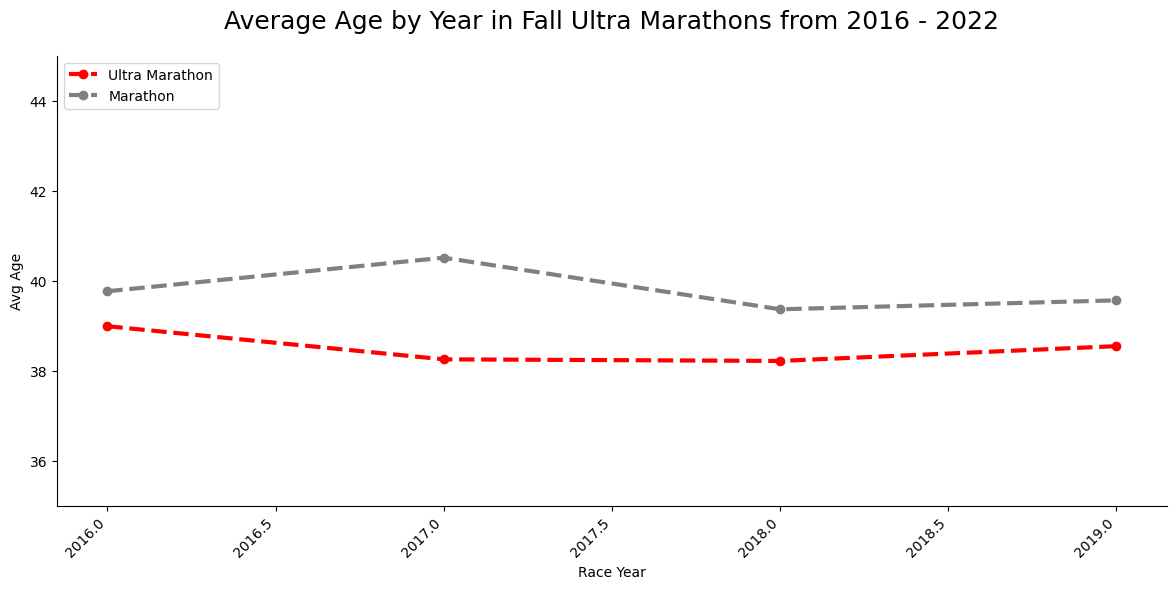

In [254]:
# Plot the average age by year for Fall Ultra Marathons 2016-2022

plt.figure(figsize=(12, 6))
plt.plot(
    um_average_age_by_year.index, 
    um_average_age_by_year.values,
    marker="o",
    linestyle = "--",
    color = "#ff0000",
    linewidth = 3)

plt.plot(
    average_age_by_year.index,
    average_age_by_year.values,
    marker="o",
    linestyle = "--",
    color = "grey",
    linewidth = 3)


plt.xlabel("Race Year")
plt.ylabel("Avg Age")
plt.title("Average Age by Year in Fall Ultra Marathons from 2016 - 2022", fontsize = 18, pad=20)
plt.xticks(rotation=45, ha ="right")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(["Ultra Marathon", "Marathon"], loc="upper left")


plt.tight_layout()

plt.ylim(35, 45)
plt.show()

<div class="alert alert-block alert-warning">
<b>My marathon</b>
</div>

In [255]:
# narrow dataset down to the marathon I completed

monumental_marathon_2019 = marathon_df[(marathon_df['Year'] == 2019) & (marathon_df['Race'] == 'Indianapolis Monumental Marathon')]
monumental_marathon_2019.head()

,Race,Year,Name,Sex,Age,Finish,Age Bracket
7838,Indianapolis Monumental Marathon,2019,Rachael Meyer,Female,24,15494,Under 35
7839,Indianapolis Monumental Marathon,2019,Andrea Kjos,Female,39,15495,35-39
7840,Indianapolis Monumental Marathon,2019,Renee Guthrie,Female,39,15495,35-39
7841,Indianapolis Monumental Marathon,2019,Jesse Maas,Female,24,15501,Under 35
7842,Indianapolis Monumental Marathon,2019,Tony Blevins,Male,44,15502,40-44


In [256]:
# create a csv of Indy Monumental

monumental_marathon_2019.to_csv('Indianapolis Monumental Marathon 2019')

In [257]:
# Get my stats

my_time = monumental_marathon_2019.iloc[2243]
my_time

Race           Indianapolis Monumental Marathon
Year                                       2019
Name                              Marie Connors
Sex                                      Female
Age                                          64
Finish                                    24687
Age Bracket                               60-64
Name: 182308, dtype: object

In [258]:
# Get average of all ages in all years

my_age = 39
total_avg_age = marathon_df['Age'].mean().astype(int)
total_avg_age


np.int64(39)

In [259]:
um_average_age = um_avg_age = um_df['Age'].mean().astype(int)
um_average_age

np.int64(38)

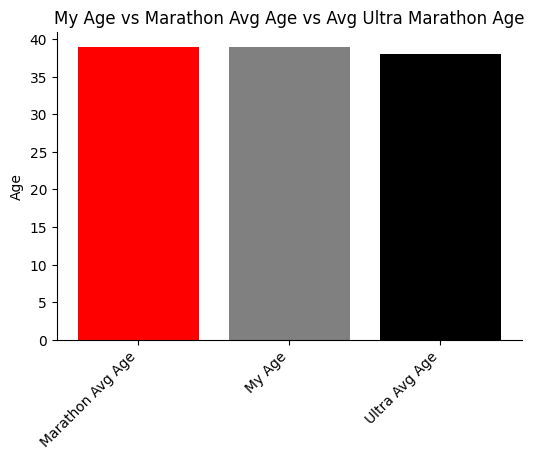

In [260]:
# compare my age to avg age for marathon finishers 2015*2019

plt.figure(figsize=(6,4))
plt.bar(['Marathon Avg Age', 'My Age', 'Ultra Avg Age'], [total_avg_age, my_age, um_average_age], color=['red', 'grey', 'black'])
plt.ylabel('Age')
plt.title('My Age vs Marathon Avg Age vs Avg Ultra Marathon Age')
plt.xticks(rotation=45, ha ="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [261]:
# Function to assing age catetory 
# Need to delete current Athlete age category column and rename Age column to Age Braket

def athlete_age_category(age):
    if age < 20:    
        return "U20"
    elif age >= 20 and age <= 25:
        return "21-25"
    elif age >= 25 and age < 30:
        return "25-29"
    elif age >= 30 and age < 35:
        return "30-34"
    elif age >= 35 and age < 40:
        return "35-39"
    elif age >= 40 and age < 45:
        return "40-44"
    elif age >= 45 and age < 50:
        return "45-49"
    elif age >= 50 and age < 55:
        return "50-54"
    elif age >= 55 and age < 60:
        return "55-59"
    elif age >= 60 and age < 65:
        return "60-64"
    elif age >= 65 and age < 70:
        return "65-69"
    elif age >= 70 and age < 75:
        return "70-74"
    elif age >= 75 and age < 80:
        return "75-79"
    elif age >= 80 and age < 85:
        return "80-84"
    elif age >= 85 and age < 90:
        return "85-89"
    else:
        return "90+"
    
um_df['Age Bracket'] = um_df['Age'].map(athlete_age_category)

<div class="alert alert-block alert-danger">
<b>Next graph</b> 
</div>

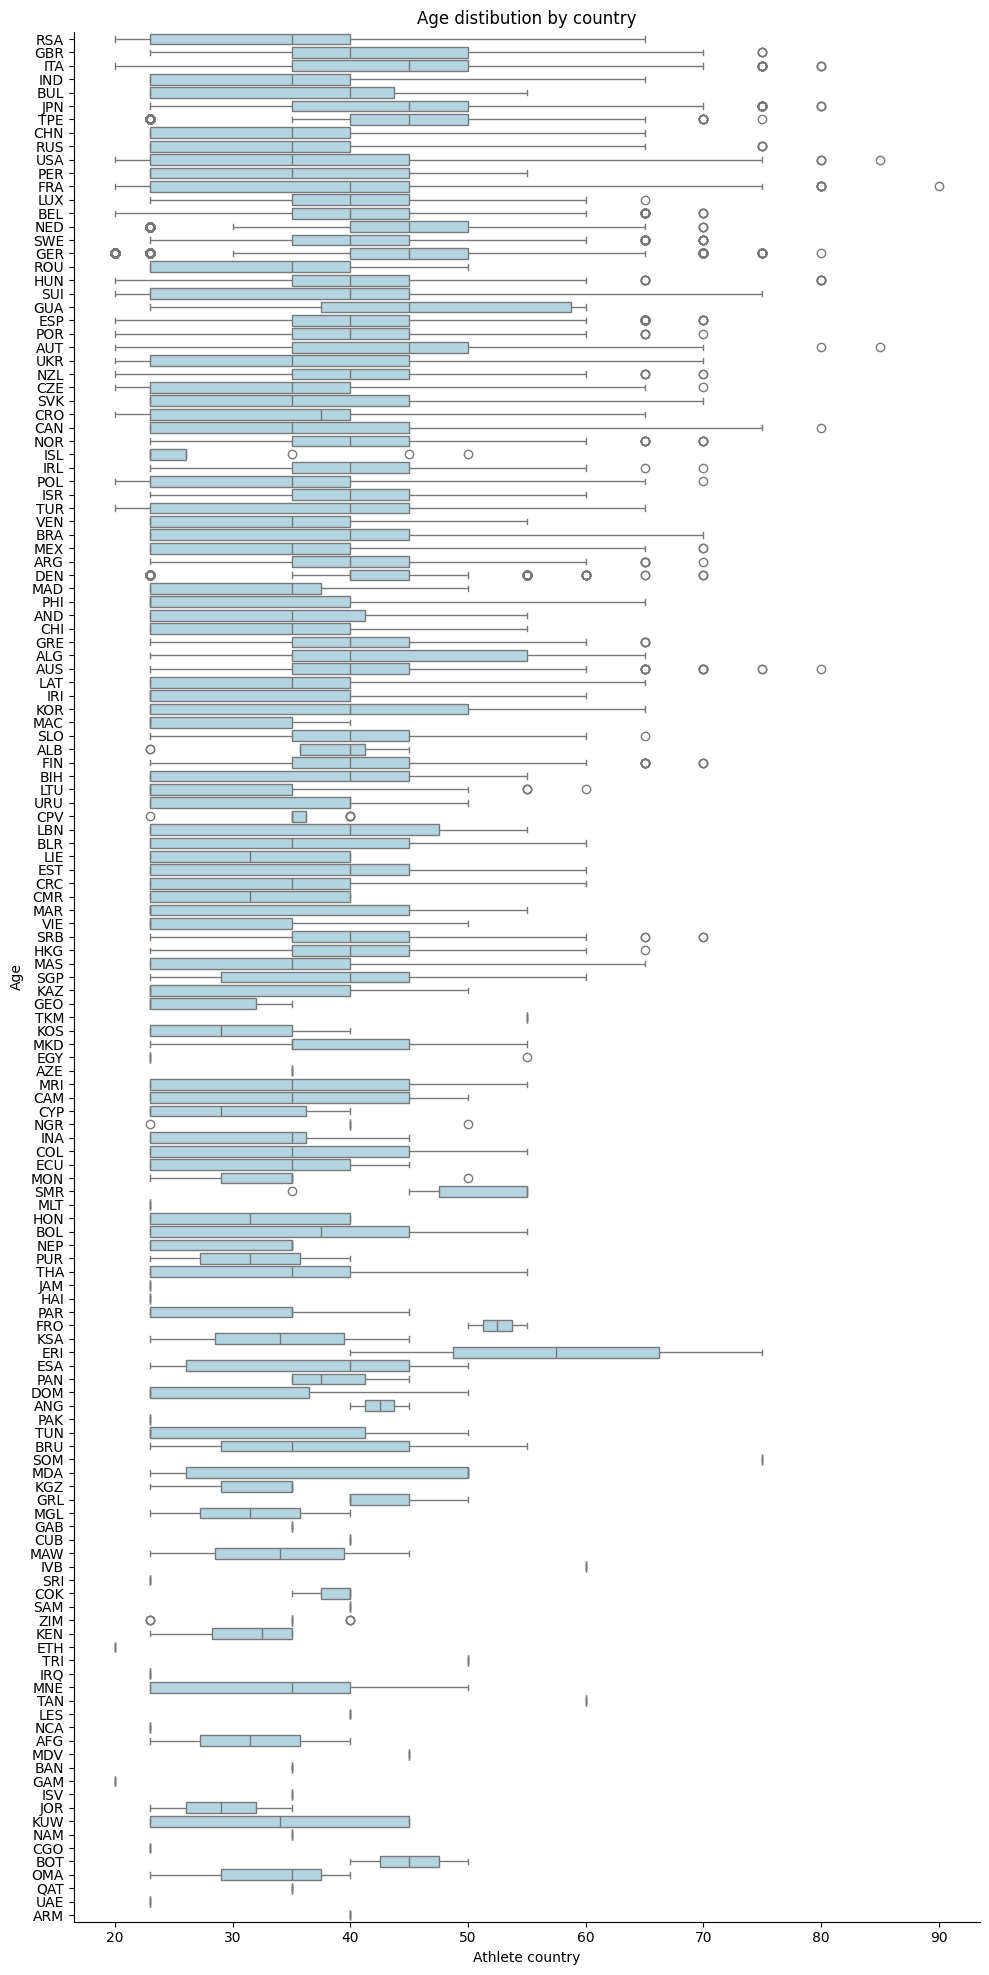

In [262]:
# use seaborn for less code and better handling of spacing

fig, ax = plt.subplots(figsize=(10, 20))

sns.boxplot(x='Age', y='Athlete country', data=um_df, color="lightblue")

plt.title('Age distibution by country')
plt.xlabel("Athlete country")
plt.ylabel("Age")


plt.suptitle("")

sns.despine(top=True, right=True)

plt.tight_layout()

plt.show()


Graph top 5-10 ages for both
SQL merge Age bracket (Group ultra by distance and age bracket?)

Coropleth by Athelte country to see if there is a country that has the most older ultra runners

<div class="alert alert-block alert-success">
<b>__Import Results_um.csv__</b> 
</div>

# Drop Athlete age category column

um_df = um_df.drop(" Athlete age category", axis='columns')


# Rename Age to Age Bracket

um_df = um_df.rename(columns={'Age': 'Age Bracket'})

In [269]:
marathon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779280 entries, 0 to 779284
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Race         779280 non-null  object
 1   Year         779280 non-null  int64 
 2   Name         779280 non-null  object
 3   Sex          779280 non-null  object
 4   Age          779280 non-null  int64 
 5   Finish       779280 non-null  int64 
 6   Age Bracket  779280 non-null  object
dtypes: int64(3), object(4)
memory usage: 47.6+ MB


In [270]:
um_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217562 entries, 0 to 217561
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Year of event              217562 non-null  int64  
 1   Event dates                217562 non-null  object 
 2   Event name                 217562 non-null  object 
 3   Event distance/length      217562 non-null  object 
 4   Event number of finishers  217562 non-null  int64  
 5   Athlete performance        217562 non-null  object 
 6   Athlete club               217562 non-null  object 
 7   Athlete country            217562 non-null  object 
 8   Athlete year of birth      217562 non-null  float64
 9   Athlete gender             217562 non-null  object 
 10  Athlete age category       217562 non-null  object 
 11  Athlete average speed      217562 non-null  object 
 12  Athlete ID                 217562 non-null  int64  
 13  Age                        217562 

In [273]:
count_age_bracket = um_df['Age Bracket'].value_counts().get('45-49',0)
print(count_age_bracket)

35471


In [ ]:
def ultra_age_bracket_totals(un_df, Age Bracket, Event number of finishers):
    

fig = px.choropleth(
    um_df,
    locationmode="country names",
    locations='Athlete country',
    featureidkey="properties.matching_world_property",
    color='Age Bracket',
    color_continuous_scale="Viridis",
    title="Age by Country in Ultra Marathons"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

marathon_age_df = ['Age Bracket']
um_age_distance_df = ['Age Bracket', 'Event distance/length']



<div class="alert alert-block alert-warning">
<b>__pd.merge(xyz_df, abc_df, on='what', how='left, right, inner')__<b>
</div>





In [264]:
with sqlite3.connect("marathon_df.db") as connection:
    cursor = connection.cursor()
    marathon_df.to_sql("um_df", connection, if_exists="replace", index=False)

In [265]:
with sqlite3.connect("um_df") as connection:
    cursor = connection.cursor()
    um_df.to_sql("um_df", connection, if_exists="replace", index=False)

create database column names in a function

total for each Age Bracket?

In [266]:
marathon_df['Age Bracket'].value_counts().info()


<class 'pandas.core.series.Series'>
Index: 11 entries, Under 35 to 80 and Over
Series name: count
Non-Null Count  Dtype
--------------  -----
11 non-null     int64
dtypes: int64(1)
memory usage: 176.0+ bytes


age_merged = pd.merge(marathon_df, miles_or_km_df, on='Age Bracket', how='inner')